# Soil X-ray CT Segmentation — Annotation Workflow

This notebook provides a simplified workflow for semi-automatic annotation of 3D soil X-ray CT images. The main processing functions are stored in the `soilct_segmentation` package, while this notebook is used to run the annotation workflow.

### Workflow

1. Load and prepare the CT image.
2. Normalize the image.
3. Initialize the soil matrix using Otsu thresholding.
4. Load or create the 3D annotation volume.
5. Open the image and labels in Napari.
6. Edit and save the annotations.

### Annotation Classes

The classes used in this project are:

- `0` — ToPredict
- `1` — Matrix
- `2` — Stones
- `3` — OrganicMatter
- `4` — Roots
- `5` — Biopores
- `6` — OtherPores

The class labels and display colors are defined in `dataset_info.json`.

### Workflow Adaptation

The annotation workflow is adapted from the
[nnUNet4SoilXrayCT](https://github.com/MaxPhal/nnUNet4SoilXrayCT)
workflow developed by Phalempin and collaborators. It has been modified here for the soil classes and preprocessing steps used in this project.

In [1]:
# Enable the Qt event loop required by Napari
%gui qt
from soilct_segmentation.pipeline import (
    launch_annotation_session,
    prepare_annotation_session,
)

## 1. Prepare the Annotation Session

Load and prepare the CT image for annotation. The workflow displays the image information, normalizes the CT volume, checks for an existing annotation, and creates the initial matrix mask when starting a new annotation.

In [ ]:
# If want help
#help(prepare_annotation_session)


Found 1 TIFF file(s):
1. LuxArbor_R1_NS_Norm_16Slices.tif
Selected file: LuxArbor_R1_NS_Norm_16Slices.tif

Soil CT Image Information
File: LuxArbor_R1_NS_Norm_16Slices.tif
Shape (Z, Y, X): (16, 2385, 2311)
Data type: uint8
Intensity range: 0 to 232

Selected middle slice: 7


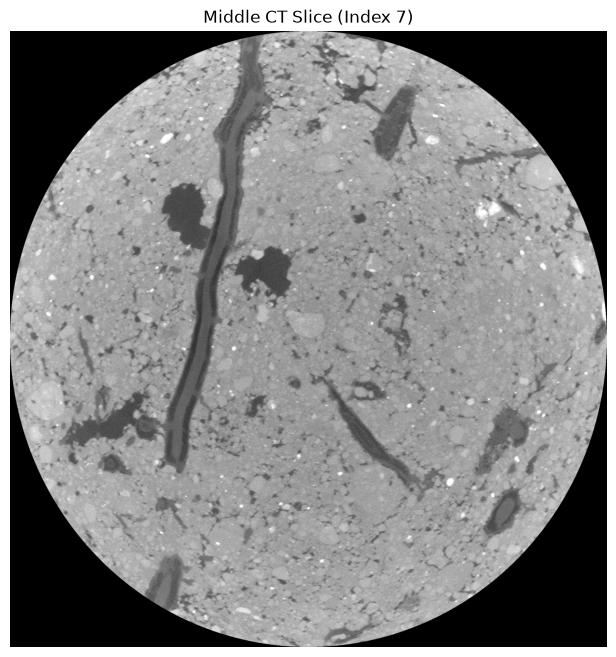

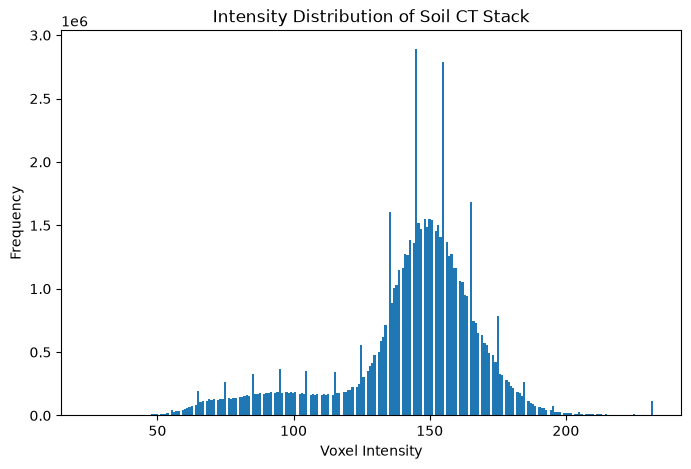

Image stack normalized to 0-255.

Existing annotation found.

Annotation Session
Input: LuxArbor_R1_NS_Norm_16Slices.tif
Image shape: (16, 2385, 2311)
Middle slice: 7
Annotation file: soilct_segmentation\Annotations\LuxArbor_R1_NS_Norm_16Slices_labels.tif
Status: Existing annotation loaded


In [2]:
# Prepare the CT image and annotation volume

session = prepare_annotation_session()

## 2. Open the Annotation in Napari

Run the next cell to open the prepared CT image and annotation volume in Napari.

The CT volume is displayed as a grayscale image layer, and the annotation is displayed as an editable labels layer.

### Saving

Annotations can be saved in two ways:

- Press **Ctrl+S** in Napari to save manually.
- Closing the Napari window saves the current annotation automatically.

Saved annotations are stored in:

`soilct_segmentation/Annotations/`

If a saved annotation already exists, it will be loaded the next time the workflow is run.

In [ ]:
# Open the prepared annotation session in Napari

viewer, label_layer, save_current_annotations = (launch_annotation_session(session))

### Working in Napari

1. Select the **Annotations** layer.
2. Navigate to the slice you want to annotate.
3. Select the label ID for the soil class you are annotating.
4. Paint or correct the labels using Napari's label tools.
5. Press **Ctrl+S** while working to save your changes.
6. Close Napari when finished. The annotation will also be saved automatically.

The saved label TIFF has the same dimensions as the input CT volume and uses the class IDs defined in `dataset_info.json`.

In [ ]:
# Optional manual save from the notebook
# save_current_annotations()

In [ ]:
# Optional: display function documentation
# help(prepare_annotation_session)